In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import sys
sys.path.append('../')

import superstats as sup

import jax
print(jax.devices())

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


[CudaDevice(id=0)]


## Constants

In [2]:
NUM_STEPS = 400
NUM_SAMPLES = 2000
NUM_EPOCHS = 100
NUM_ITER_PER_EPOCH = 1000
BATCH_SIZE = 32

## Prior

In [3]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    a = sup.transition.RandomWalk(
            bounds=(0.0, 4.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=0.0, scale=0.5)
        ),
    tau = sup.transition.RandomWalk(
            bounds=(0.0, 2.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    bias = 0.5
)

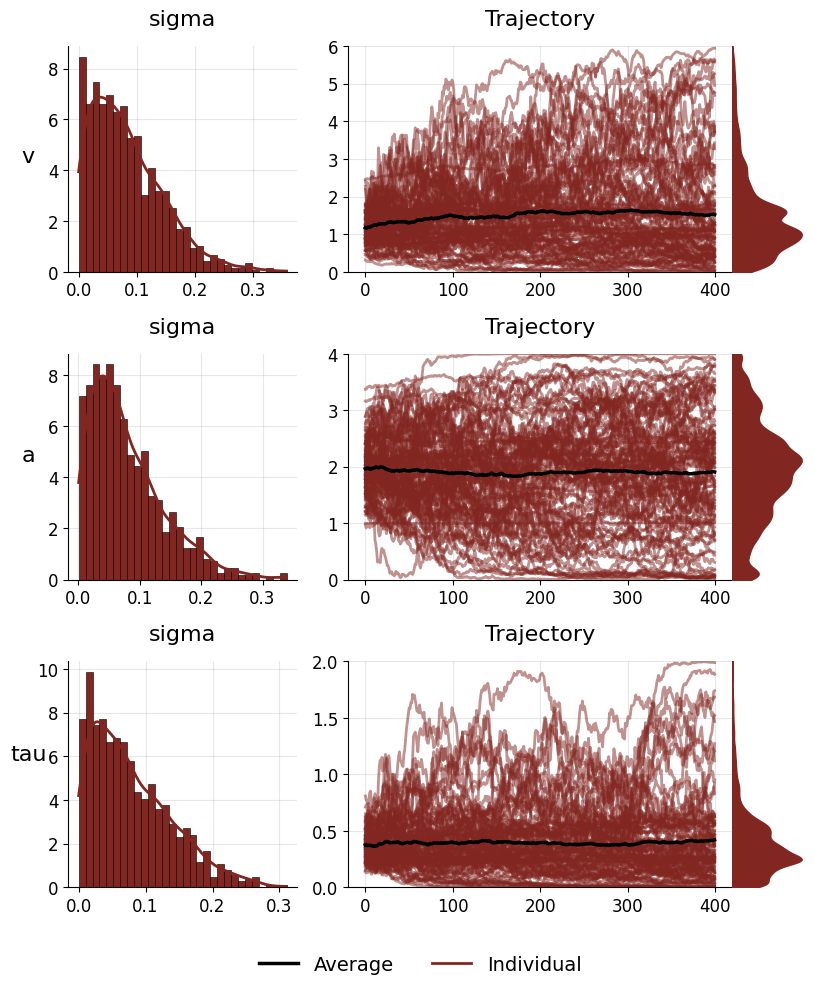

In [4]:
fig = joint_prior.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_trajectories=100,
)

## Generative Model

In [5]:
ddm = sup.simulation.sample_ddm

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

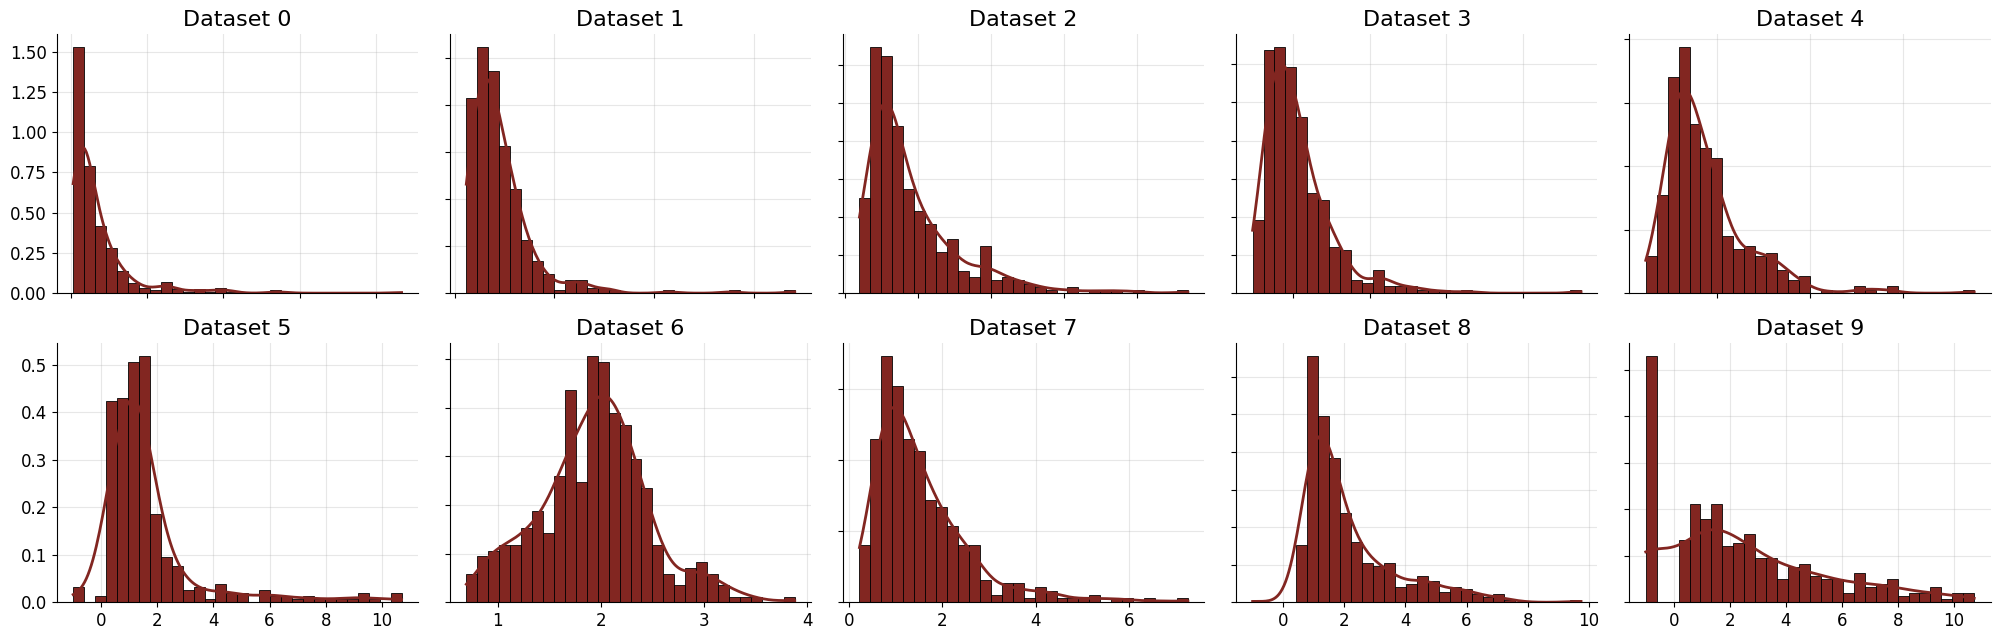

In [6]:
fig = generative_model.plot_push_forward(
    num_sim=10,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    num_cols=5,
)

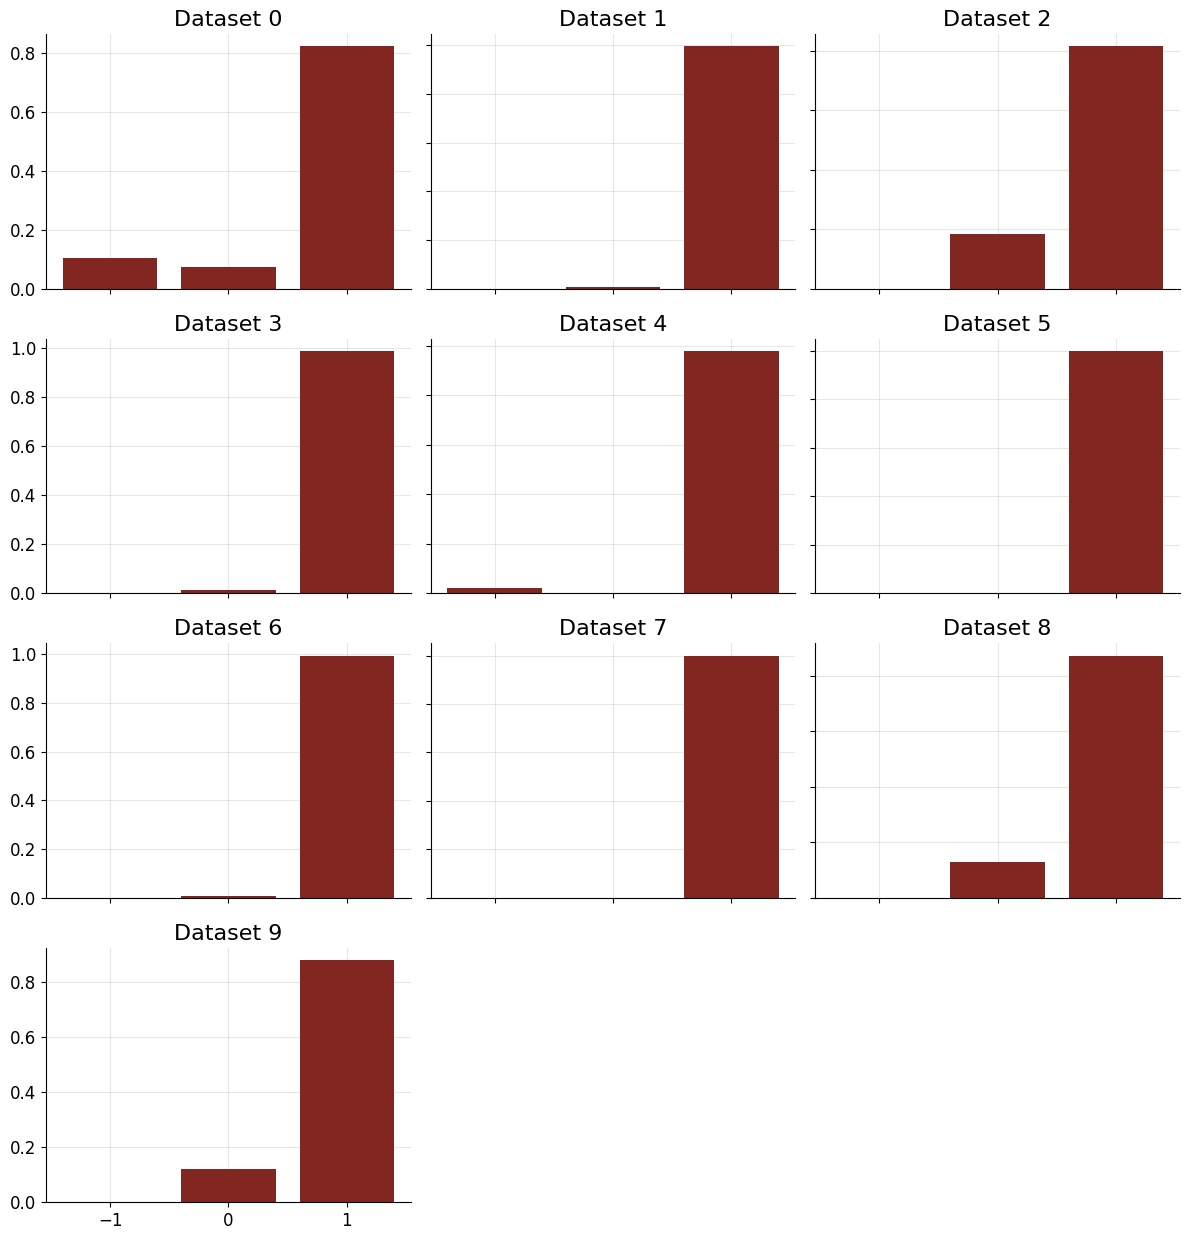

In [7]:
fig = generative_model.plot_push_forward(
    num_sim=10,
    num_steps=NUM_STEPS,
    data_dim=1,
    kind="dist",
)

## Workflow

In [8]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="ddm_benchmark"
)

/scratch/schuma0018/slurm-job.16686516/ipykernel_2282827/2345476879.py:1: UserWarning: restore_approximator=True but no model found at 'ddm_benchmark'. Starting with no trained model.
  workflow = sup.workflow.Workflow(
/scratch/schuma0018/slurm-job.16686516/ipykernel_2282827/2345476879.py:1: UserWarning: restore_history=True but no history found at 'ddm_benchmark'. Starting with no history.
  workflow = sup.workflow.Workflow(


## Training

In [9]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=NUM_EPOCHS,
    num_batches_per_epoch=NUM_ITER_PER_EPOCH,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 100ms/step - loss: -1.3850
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - loss: -2.5427
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - loss: -2.6949
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - loss: -2.7375
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 124s 124ms/step - loss: -2.7538
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - loss: -2.7606
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 102s 102ms/step - loss: -2.7695
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - loss: -2.7779
Epoch 9/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - loss: -2.7853
Epoch 10/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 96s 96ms/step - loss: -2.7952  
Epoch 11/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 96s 96ms/step - loss: -2.8001  
Epoch 12/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 97s 97ms/step - loss: -2.8037  
Epoch 13/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 97s 97ms/step - loss: -2.8089 
Epoch 14/100
1000/1000

INFO:bayesflow:Training completed in 3.15 hours.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'ddm_benchmark/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("ddm_benchmark/model.keras")


In [ ]:
fig = workflow.plot_history(history)